# GNN(Graph Neural Network) 実践的学習教材

このノートブックでは、グラフと線形代数を学習済みの人を対象に、GNNの基本的な考え方からGCN(Graph Convolutional Network)の実装・学習・評価までを扱います。

扱う内容:

- メッセージパッシングとしてのGNN
- GCNの数式と正規化隣接行列
- PyTorchによるGCNのフルスクラッチ実装
- 合成グラフ上の半教師ありノード分類（一部のノードだけに正解ラベルがある学習）
- オーバースムージングの観察
- GraphSAGE / GAT / グラフ分類への拡張の見取り図

外部データセットに依存しないよう、Stochastic Block Model風の合成グラフを使います。

## 0. 依存関係

この教材の実装部分では `numpy`, `matplotlib`, `torch` を使います。PyTorchが未導入の場合は、環境に合う方法でインストールしてください。

```bash
pip install torch numpy matplotlib
```

GPUは必須ではありません。小さな合成グラフを使うためCPUで十分です。

描画、グラフ統計、Coraデータの読み込みなど、説明の本筋ではない補助処理は `gnn_tutorial_utils.py` に分けています。ノートブック側ではGCNやGraphSAGEの考え方に直接関わるコードを中心に残します。


In [28]:
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "PyTorchが見つかりません。ノートブック上で `pip install torch` を実行するか、"
        "PyTorchが入った環境で開き直してください。"
    ) from e

from gnn_tutorial_utils import (
    accuracy,
    describe_graph,
    load_cora,
    neighborhood_sample,
    plot_graph,
    plot_multiclass_graph,
    set_seed,
)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 1. GNNをメッセージパッシングとして見る

グラフを $G=(V,E)$、ノード $v \in V$ の第 $k$ 層の表現を $h_v^{(k)}$ とします。多くのGNNは、近傍ノード$\mathcal{N}(v)$から情報を集約して自ノード表現を更新する次の形で書けます。

$$
m_v^{(k)} = \operatorname{AGG}^{(k)}\left(\{h_u^{(k-1)} : u \in \mathcal{N}(v)\}\right)
$$

`AGG` は aggregation（集約）の略で、近傍ノード集合 $\mathcal{N}(v)$ に含まれる各ノードの表現 $h_u^{(k-1)}$ を1つのメッセージ $m_v^{(k)}$ にまとめる関数です。たとえば平均を取る場合は、近傍ノードの特徴ベクトルを平均して「周囲から届く情報」として使います。

$$
h_v^{(k)} = \operatorname{UPDATE}^{(k)}\left(h_v^{(k-1)}, m_v^{(k)}\right)
$$

ここで重要なのは、`AGG` が近傍ノード集合に対して順序不変であることです。グラフの隣接ノードには自然な順序がないため、平均・和・最大値・注意重み付き和などがよく使われます。

ノード特徴行列を $X \in \mathbb{R}^{N \times F}$、隣接行列を $A \in \{0,1\}^{N \times N}$ とすると、行列演算としては「隣接行列で近傍特徴を混ぜる」操作が中心になります。

## 2. GCNの定式化

GCN(Kipf & Welling, 2017)の代表的な層は次の式で表されます。

$$
H^{(l+1)} = \sigma\left(\tilde{D}^{-\frac{1}{2}} \tilde{A} \tilde{D}^{-\frac{1}{2}} H^{(l)} W^{(l)}\right)
$$

いきなりこの式を見ると少し硬いので、まずは小さな行列で「GCNが何をしているか」を見ます。

### 小さなグラフで見るGCN

3個のノードが次のようにつながっているとします。

```text
node 0 ── node 1 ── node 2
```

各ノードが2次元の特徴量を持つとします。行がノード、列が特徴量です。

$$
X =
\begin{bmatrix}
1 & 0 \\
0 & 1 \\
1 & 1
\end{bmatrix}
\quad
\begin{array}{l}
\leftarrow \text{node 0 の特徴} \\
\leftarrow \text{node 1 の特徴} \\
\leftarrow \text{node 2 の特徴}
\end{array}
$$

このグラフの隣接行列 $A$ は次のようになります。`1` は辺があること、`0` は辺がないことを表します。

$$
A =
\begin{bmatrix}
0 & 1 & 0 \\
1 & 0 & 1 \\
0 & 1 & 0
\end{bmatrix}
$$

GCNでは、自分自身の特徴も次の層へ渡したいので、自己ループを追加します。

$$
\tilde{A} = A + I =
\begin{bmatrix}
1 & 1 & 0 \\
1 & 1 & 1 \\
0 & 1 & 1
\end{bmatrix}
$$

ここではまず、説明を簡単にするために「つながっているノードの平均」を取る行列 $S$ を使います。実際のGCNではこの後に出てくる対称正規化 $\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}$ を使いますが、直感は同じです。

$$
S =
\begin{bmatrix}
1/2 & 1/2 & 0 \\
1/3 & 1/3 & 1/3 \\
0 & 1/2 & 1/2
\end{bmatrix}
$$

この $S$ を特徴行列 $X$ に掛けると、各ノードの特徴が「自分 + 近傍」の平均に置き換わります。

$$
S X =
\begin{bmatrix}
1/2 & 1/2 & 0 \\
1/3 & 1/3 & 1/3 \\
0 & 1/2 & 1/2
\end{bmatrix}
\begin{bmatrix}
1 & 0 \\
0 & 1 \\
1 & 1
\end{bmatrix}
=
\begin{bmatrix}
0.5 & 0.5 \\
0.67 & 0.67 \\
0.5 & 1.0
\end{bmatrix}
$$

行ごとに見ると、次の計算をしています。

```text
node 0 の新しい特徴 = (node 0 の特徴 + node 1 の特徴) / 2
                   = ([1, 0] + [0, 1]) / 2
                   = [0.5, 0.5]

node 1 の新しい特徴 = (node 0 の特徴 + node 1 の特徴 + node 2 の特徴) / 3
                   = ([1, 0] + [0, 1] + [1, 1]) / 3
                   = [0.67, 0.67]

node 2 の新しい特徴 = (node 1 の特徴 + node 2 の特徴) / 2
                   = ([0, 1] + [1, 1]) / 2
                   = [0.5, 1.0]
```

つまり、GCNの前半は「グラフでつながっているノードの特徴を混ぜる」処理です。

```text
元の特徴 X                 グラフで近傍平均 S@X
node 0: [1, 0]      ──>    node 0: [0.5, 0.5]
node 1: [0, 1]      ──>    node 1: [0.67, 0.67]
node 2: [1, 1]      ──>    node 2: [0.5, 1.0]
```

次に、学習可能な重み $W$ を掛けて、特徴量を分類しやすい表現へ変換します。例えば2次元特徴を2クラスのスコアへ変換するなら、$W$ は $(2, 2)$ の行列です。

$$
W =
\begin{bmatrix}
2 & -1 \\
-1 & 2
\end{bmatrix}
$$

$$
S X W =
\begin{bmatrix}
0.5 & 0.5 \\
0.67 & 0.67 \\
0.5 & 1.0
\end{bmatrix}
\begin{bmatrix}
2 & -1 \\
-1 & 2
\end{bmatrix}
=
\begin{bmatrix}
0.5 & 0.5 \\
0.67 & 0.67 \\
0.0 & 1.5
\end{bmatrix}
$$

この出力も行がノードです。列はクラスや隠れ特徴に対応します。

```text
S @ X          : 近傍情報を混ぜた特徴
S @ X @ W      : 学習可能な重みで変換した特徴またはクラススコア
ReLU(...)      : 必要に応じて負の値を0にする非線形変換
```

### 実際のGCNの式

上の例では理解しやすくするために単純な平均を使いました。実際のGCNでは、次数の大きいノードの影響が強くなりすぎないように、次の正規化隣接行列を使います。

$$
S = \tilde{D}^{-\frac{1}{2}} \tilde{A} \tilde{D}^{-\frac{1}{2}}
$$

この $S$ を使うと、GCNの1層は次の形になります。

$$
H^{(l+1)} = \sigma\left(S H^{(l)} W^{(l)}\right)
$$

ただし、

- $H^{(0)} = X$
- $\tilde{A} = A + I_N$ は自己ループを追加した隣接行列
- $\tilde{D}_{ii} = \sum_j \tilde{A}_{ij}$ は次数行列
- $W^{(l)}$ は学習可能な重み
- $\sigma$ はReLUなどの非線形関数

2層GCNでノード分類する場合は、概ね次の流れになります。

```text
X (N,F)
  │
  │  S @ X @ W0
  ▼
H1 (N,H)
  │
  │  S @ H1 @ W1
  ▼
Z (N,C)
```

ここで $Z$ の1行が1ノードに対応し、その行の $C$ 個の値が「そのノードが各クラスらしい度合い」を表します。


## 3. 合成グラフデータを作る

ここでは2クラスのノード分類問題を作ります。同じクラス同士は接続されやすく、異なるクラス同士は接続されにくいグラフを生成します。これはコミュニティ構造を持つグラフの簡単なモデルです。

特徴量は、クラスごとに異なる平均ベクトルからノイズ付きで生成します。少数のラベル付きノードだけを訓練に使い、残りを検証・テストに使います。

In [29]:
@dataclass
class GraphData:
    x: torch.Tensor
    y: torch.Tensor
    adj: torch.Tensor
    train_mask: torch.Tensor
    val_mask: torch.Tensor
    test_mask: torch.Tensor


def make_sbm_node_classification(
    n_per_class: int = 100,
    feature_dim: int = 16,
    p_in: float = 0.12,
    p_out: float = 0.015,
    train_per_class: int = 10,
    val_per_class: int = 20,
) -> GraphData:
    n_classes = 2
    n = n_per_class * n_classes
    y_np = np.repeat(np.arange(n_classes), n_per_class)

    # クラスごとの平均をずらし、特徴だけでも少し識別できるが完全ではない設定にする。
    means = np.zeros((n_classes, feature_dim), dtype=np.float32)
    means[0, : feature_dim // 2] = 0.8
    means[1, feature_dim // 2 :] = 0.8
    x_np = means[y_np] + np.random.normal(scale=0.9, size=(n, feature_dim)).astype(np.float32)

    adj_np = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        for j in range(i + 1, n):
            p = p_in if y_np[i] == y_np[j] else p_out
            if np.random.rand() < p:
                adj_np[i, j] = 1.0
                adj_np[j, i] = 1.0

    train_mask_np = np.zeros(n, dtype=bool)
    val_mask_np = np.zeros(n, dtype=bool)
    test_mask_np = np.zeros(n, dtype=bool)

    for c in range(n_classes):
        idx = np.where(y_np == c)[0]
        np.random.shuffle(idx)
        train_idx = idx[:train_per_class]
        val_idx = idx[train_per_class : train_per_class + val_per_class]
        test_idx = idx[train_per_class + val_per_class :]
        train_mask_np[train_idx] = True
        val_mask_np[val_idx] = True
        test_mask_np[test_idx] = True

    return GraphData(
        x=torch.tensor(x_np, dtype=torch.float32),
        y=torch.tensor(y_np, dtype=torch.long),
        adj=torch.tensor(adj_np, dtype=torch.float32),
        train_mask=torch.tensor(train_mask_np),
        val_mask=torch.tensor(val_mask_np),
        test_mask=torch.tensor(test_mask_np),
    )


data = make_sbm_node_classification()
print(data.x.shape, data.adj.shape, data.y.shape)
print("num_edges:", int(data.adj.sum().item() / 2))
print("train/val/test:", data.train_mask.sum().item(), data.val_mask.sum().item(), data.test_mask.sum().item())

torch.Size([200, 16]) torch.Size([200, 200]) torch.Size([200])
num_edges: 1290
train/val/test: 20 40 140


nodes: 200
edges: 1290
avg degree: 12.90
min/max degree: 4 / 25


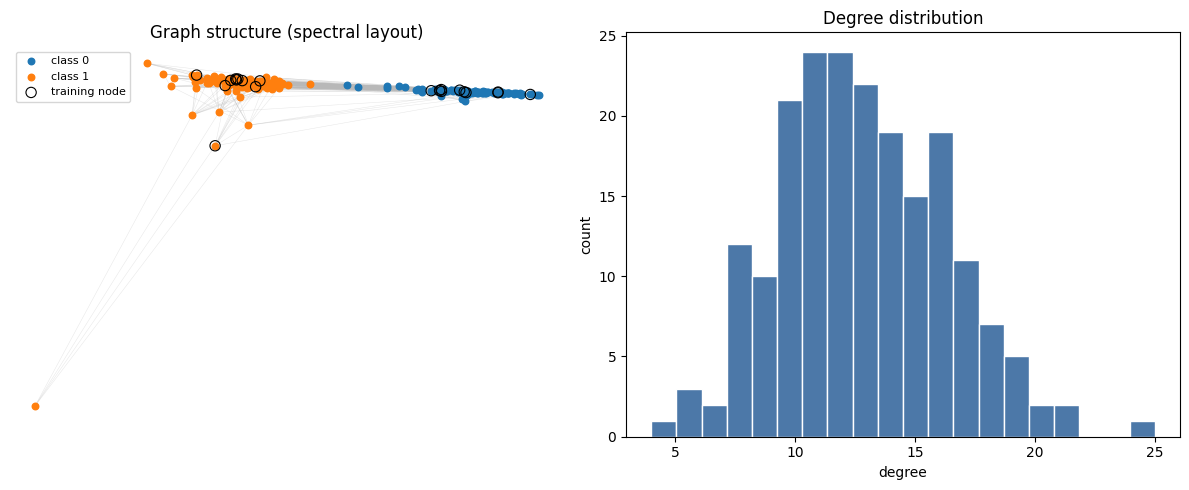

In [30]:
describe_graph(data.adj)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_graph(data.adj, data.y, data.train_mask, axes[0])
axes[1].hist(data.adj.sum(dim=1).numpy(), bins=20, color="#4C78A8", edgecolor="white")
axes[1].set_xlabel("degree")
axes[1].set_ylabel("count")
axes[1].set_title("Degree distribution")
plt.tight_layout()
plt.show()


## 4. GCN用の正規化隣接行列

GCNでは自己ループを足してから対称正規化します。

$$
\hat{A} = \tilde{D}^{-\frac{1}{2}} \tilde{A} \tilde{D}^{-\frac{1}{2}}, \quad \tilde{A}=A+I
$$

この $\hat{A}$ は、各層で特徴表現を近傍へ拡散させる行列として働きます。

In [31]:
def normalize_adjacency(adj: torch.Tensor) -> torch.Tensor:
    n = adj.size(0)
    adj_tilde = adj + torch.eye(n, device=adj.device)
    degree = adj_tilde.sum(dim=1)
    degree_inv_sqrt = degree.pow(-0.5)
    degree_inv_sqrt[torch.isinf(degree_inv_sqrt)] = 0.0
    d_inv_sqrt = torch.diag(degree_inv_sqrt)
    return d_inv_sqrt @ adj_tilde @ d_inv_sqrt

adj_norm = normalize_adjacency(data.adj)
print(adj_norm.shape)
print("symmetric:", torch.allclose(adj_norm, adj_norm.T, atol=1e-6))

torch.Size([200, 200])
symmetric: True


## 5. GCN層を実装する

GCN層は次の2段階で考えられます。

1. 特徴変換: $H W$
2. 近傍集約: $\hat{A} H W$

実装では、まず線形変換 `nn.Linear` を適用し、その後に正規化隣接行列を掛けます。順番を $\hat{A}H$ の後に $W$ としても数学的には同じですが、疎行列実装や次元数によって効率が変わります。

In [32]:
class GCNLayer(nn.Module):
    def __init__(self, in_dim: int, out_dim: int):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim, bias=False)

    def forward(self, x: torch.Tensor, adj_norm: torch.Tensor) -> torch.Tensor:
        support = self.linear(x)
        return adj_norm @ support


class GCN(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, dropout: float = 0.5):
        super().__init__()
        self.conv1 = GCNLayer(in_dim, hidden_dim)
        self.conv2 = GCNLayer(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x: torch.Tensor, adj_norm: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x, adj_norm)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, adj_norm)
        return x


model = GCN(in_dim=data.x.size(1), hidden_dim=32, out_dim=2).to(device)
model

GCN(
  (conv1): GCNLayer(
    (linear): Linear(in_features=16, out_features=32, bias=False)
  )
  (conv2): GCNLayer(
    (linear): Linear(in_features=32, out_features=2, bias=False)
  )
)

## 6. 半教師ありノード分類として学習する

### 半教師あり学習とは

半教師あり学習は、**正解ラベルが付いた少数のデータ**と、**正解ラベルが付いていない多数のデータ**を一緒に利用する学習方法です。すべての訓練データに正解がある教師あり学習と、正解をまったく使わない教師なし学習の中間に位置します。

### どのような場面で使うか

半教師あり学習は、データ自体は大量に集められる一方、専門家による確認や人手でのラベル付けに時間と費用がかかる場面で使われます。代表例は次のとおりです。

- **引用ネットワーク**: 論文と引用関係は取得できるが、全論文への研究分野ラベル付けは手間がかかる
- **SNSや会員ネットワーク**: ユーザーとつながりは取得できるが、興味・属性・不正利用などの正解ラベルは一部しか確認できない
- **不正取引検知**: 取引履歴は大量にあるが、調査によって不正と確定した事例は少ない
- **医療画像や文書分類**: 画像や文書は大量にあるが、医師や専門家による判定コストが高い

### どのような効果があるか

少数のラベル付きデータだけで教師あり学習する場合と比べて、未ラベルデータの特徴分布やデータ同士の関係を利用できるため、一般に次の効果が期待できます。

- ラベル付けの件数と費用を抑えながら、分類対象を広げられる
- 少数のラベルだけで学習する場合より、未知データに対する分類精度が改善することがある
- GNNでは、周囲のノード特徴量を集約することで、単独では情報が少ないノードも分類しやすくなる

ただし、未ラベルデータを増やせば必ず精度が上がるわけではありません。GNNによる半教師あり学習では、**接続されたノードは同じクラスや似た特徴を持ちやすい**という傾向があると特に有効です。接続関係がラベルと無関係だったり、異なるクラス同士が主に接続されていたりすると、近傍集約が誤った情報を混ぜて精度を下げる場合があります。セクション10の `weak graph signal` は、この条件が弱くなった場合を確認する実験です。

### ここでGCNは何を計算しているか

セクション2の式を、学習の文脈でもう一度書くと次のようになります。

$$
S = \tilde{D}^{-\frac{1}{2}} \tilde{A} \tilde{D}^{-\frac{1}{2}}
$$

$$
H^{(1)} = \operatorname{ReLU}(S X W^{(0)})
$$

$$
Z = S H^{(1)} W^{(1)}
$$

ここで、$X$ は全ノードの特徴量、$S$ は自己ループ付きで正規化した隣接行列、$Z$ はGCNの最終出力です。$Z$ の形は $(N, C)$ で、$N$ はノード数、$C$ はクラス数です。したがって、$Z$ の1行が1ノードに対応し、その行の値が各クラスのスコアになります。

```text
全ノードの特徴 X (N,F)
        │
        │  S で近傍の特徴を集約し、W0 で隠れ表現へ変換
        ▼
隠れ表現 H1 (N,H)
        │
        │  S でもう一度近傍を集約し、W1 でクラススコアへ変換
        ▼
出力ロジット Z (N,C)
        │
        │  train_mask=True の行だけを取り出す
        ▼
損失計算に使う Z_train と y_train
```

このノートブックでは、200個すべてのノードについて次の情報をGCNへ入力します。

- ノード特徴量 `data.x`
- ノード間の接続関係 `data.adj`

一方、訓練時に正解クラス `data.y` を見せるのは、`data.train_mask` が `True` の20ノードだけです。残りのノードには特徴量と接続関係はありますが、その正解ラベルを損失計算には使いません。GCNは接続されたノードの特徴量を集約し、少数の正解ラベルから学んだ分類規則を使って、ラベルが与えられていないノードも分類します。正解ラベルそのものを隣接ノードへ入力しているわけではありません。

各マスクの役割は次のとおりです。

- `train_mask`: 損失を計算し、モデルの重みを更新するノード
- `val_mask`: 学習中のモデル選択やハイパーパラメータ調整に使うノード
- `test_mask`: 最終的な汎化性能を測るノード（モデル選択や重み更新には使わない）

したがって、GCNは全ノードの特徴とグラフ構造を使って表現を計算しますが、損失はラベル付き訓練ノードに対してのみ計算します。コードでは `logits[data.train_mask]` と `data.y[data.train_mask]` がこの操作に対応します。

$$
\mathcal{L} = -\sum_{v \in \mathcal{V}_{train}} \log p_{v, y_v}
$$

ここで $p_v = \operatorname{softmax}(z_v)$、$z_v$ はGCNの出力ロジットです。この設定は **transductive（推移的）** なノード分類と呼ばれます。訓練時点で検証・テストノードを含むグラフ全体の特徴量と接続関係は利用できますが、それらの正解ラベルは利用しません。Coraなどの引用ネットワークでよく使われる設定です。


In [33]:
data = GraphData(
    x=data.x.to(device),
    y=data.y.to(device),
    adj=data.adj.to(device),
    train_mask=data.train_mask.to(device),
    val_mask=data.val_mask.to(device),
    test_mask=data.test_mask.to(device),
)
adj_norm = normalize_adjacency(data.adj).to(device)



def train_gcn(model: nn.Module, epochs: int = 200, lr: float = 0.01, weight_decay: float = 5e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = []
    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(data.x, adj_norm)
        loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits = model(data.x, adj_norm)
            train_acc = accuracy(logits, data.y, data.train_mask)
            val_acc = accuracy(logits, data.y, data.val_mask)
            test_acc = accuracy(logits, data.y, data.test_mask)

        history.append({
            "epoch": epoch,
            "loss": loss.item(),
            "train_acc": train_acc,
            "val_acc": val_acc,
            "test_acc": test_acc,
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 20 == 0 or epoch == 1:
            print(
                f"epoch={epoch:03d} loss={loss.item():.4f} "
                f"train={train_acc:.3f} val={val_acc:.3f} test={test_acc:.3f}"
            )

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    return history


set_seed(42)
model = GCN(in_dim=data.x.size(1), hidden_dim=32, out_dim=2, dropout=0.5).to(device)
history = train_gcn(model)


epoch=001 loss=0.7180 train=0.950 val=0.975 test=0.936
epoch=020 loss=0.0212 train=1.000 val=1.000 test=1.000
epoch=040 loss=0.0006 train=1.000 val=1.000 test=1.000
epoch=060 loss=0.0005 train=1.000 val=1.000 test=1.000
epoch=080 loss=0.0004 train=1.000 val=1.000 test=1.000
epoch=100 loss=0.0006 train=1.000 val=1.000 test=1.000
epoch=120 loss=0.0004 train=1.000 val=1.000 test=1.000
epoch=140 loss=0.0015 train=1.000 val=1.000 test=1.000
epoch=160 loss=0.0006 train=1.000 val=1.000 test=1.000
epoch=180 loss=0.0007 train=1.000 val=1.000 test=1.000
epoch=200 loss=0.0008 train=1.000 val=1.000 test=1.000


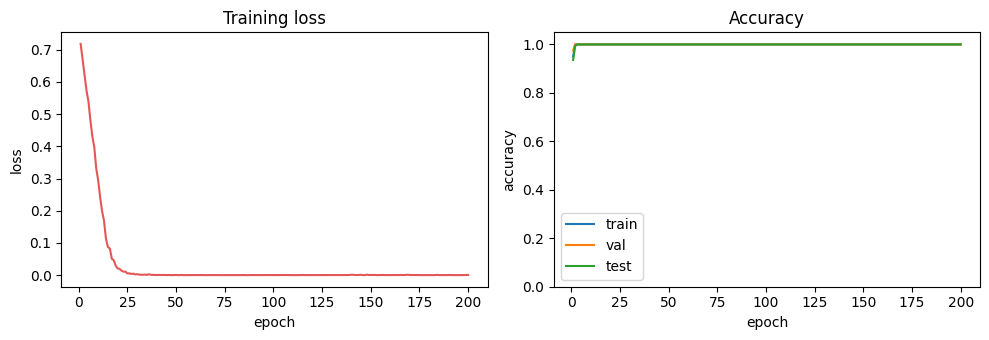

best val accuracy: 1.0
test accuracy: 0.9928571581840515


In [34]:
epochs = [row["epoch"] for row in history]
losses = [row["loss"] for row in history]
train_accs = [row["train_acc"] for row in history]
val_accs = [row["val_acc"] for row in history]
test_accs = [row["test_acc"] for row in history]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(epochs, losses, color="#E45756")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Training loss")

axes[1].plot(epochs, train_accs, label="train")
axes[1].plot(epochs, val_accs, label="val")
axes[1].plot(epochs, test_accs, label="test")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].set_title("Accuracy")
plt.tight_layout()
plt.show()

model.eval()
with torch.no_grad():
    logits = model(data.x, adj_norm)
    print("best val accuracy:", accuracy(logits, data.y, data.val_mask))
    print("test accuracy:", accuracy(logits, data.y, data.test_mask))

## 7. 比較: グラフ構造を使わないMLP

GCNの効果を見るため、同じ特徴量だけを使うMLPと比較します。MLPは $A$ を使わないため、近傍ノードの情報を利用できません。

$$
Z = \operatorname{MLP}(X)
$$

この合成データでは特徴量にも信号を入れているためMLPもある程度は分類できますが、グラフ構造が有用な場合はGCNが有利になりやすいです。

In [35]:
class MLP(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, dropout: float = 0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def train_mlp(model: nn.Module, epochs: int = 200, lr: float = 0.01, weight_decay: float = 5e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_val_acc = -1.0
    best_state = None
    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(data.x)
        loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits = model(data.x)
            val_acc = accuracy(logits, data.y, data.val_mask)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})


set_seed(42)
mlp = MLP(in_dim=data.x.size(1), hidden_dim=32, out_dim=2, dropout=0.5).to(device)
train_mlp(mlp)
mlp.eval()
with torch.no_grad():
    mlp_logits = mlp(data.x)
    print("MLP val accuracy:", accuracy(mlp_logits, data.y, data.val_mask))
    print("MLP test accuracy:", accuracy(mlp_logits, data.y, data.test_mask))

MLP val accuracy: 1.0
MLP test accuracy: 0.9285714030265808


## 8. オーバースムージングを観察する

GCN層を深く積みすぎると、ノード表現が似通ってしまうことがあります。これはオーバースムージングと呼ばれます。

単純化して重みと非線形性を無視すると、GCNの反復は次のようになります。

$$
H^{(k)} = \hat{A}^k X
$$

$k$ が大きくなると、連結成分内のノード表現が平滑化され、クラス境界を表す情報が弱くなることがあります。以下では、反復的に $\hat{A}$ を掛けたときのノード表現間の平均コサイン類似度を見ます。

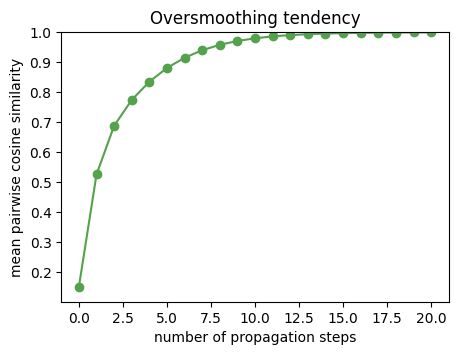

In [36]:
def mean_pairwise_cosine(x: torch.Tensor) -> float:
    x_norm = F.normalize(x, p=2, dim=1)
    sim = x_norm @ x_norm.T
    n = x.size(0)
    off_diag = sim[~torch.eye(n, dtype=torch.bool, device=x.device)]
    return off_diag.mean().item()


h = data.x.clone()
steps = list(range(21))
cosines = []
for k in steps:
    cosines.append(mean_pairwise_cosine(h))
    h = adj_norm @ h

plt.figure(figsize=(5, 3.5))
plt.plot(steps, cosines, marker="o", color="#54A24B")
plt.xlabel("number of propagation steps")
plt.ylabel("mean pairwise cosine similarity")
plt.title("Oversmoothing tendency")
plt.ylim(min(cosines) - 0.05, 1.0)
plt.show()

## 9. GCNから他のGNNへ

ここまで扱ったGCNは、GNNの基本を理解するには今でも非常に重要です。一方で、最近の実験や実務ではGCNだけでなく、GraphSAGEやGATも標準的な比較対象としてよく使われます。2024年の再評価研究でも、GCN・GraphSAGE・GATのような古典的GNNは、適切にチューニングすると新しいGraph Transformer系モデルに対しても強いベースラインになることが報告されています。

この教材では、GCNと同じメッセージパッシングの考え方で理解しやすく、実装も軽い **GraphSAGE** を追加で扱います。GATも重要ですが、注意係数をエッジごとに計算するため実装量が増えます。まずはGCNとGraphSAGEを比較すると、「隣接ノードをどう集約するか」がモデルごとに違うことを見やすくなります。

### GCN(Graph Convolutional Network)

GCNは正規化した隣接行列を使い、自分自身と隣接ノードの特徴をまとめて集約するモデルです。1層の計算は概ね次の形です。

$$
S = \tilde{D}^{-\frac{1}{2}} \tilde{A} \tilde{D}^{-\frac{1}{2}}
$$

$$
h_v^{(k)} = \sigma\left(\sum_{u \in \mathcal{N}(v) \cup \{v\}} S_{vu} h_u^{(k-1)} W^{(k)}\right)
$$

行列で書くと、セクション2で見た次の式になります。

$$
H^{(k)} = \sigma\left(S H^{(k-1)} W^{(k)}\right)
$$

GCNの特徴は、近傍ノードへの重みを学習するのではなく、グラフの次数にもとづく正規化係数 $S_{vu}$ で固定する点です。そのため実装がシンプルで計算も比較的軽く、引用ネットワークのように「つながっているノードは似たクラスになりやすい」グラフでは強いベースラインになります。一方で、どの隣接ノードを重視するかをノードごとに柔軟に変えることは苦手です。

### GraphSAGE

GraphSAGEは近傍サンプリングと集約関数を使い、大規模グラフや未知ノードへの inductive な汎化を意識したモデルです。平均集約の場合は概ね次の形です。

$$
m_v^{(k)} = \operatorname{mean}\left(\{h_u^{(k-1)} : u \in \mathcal{N}(v)\}\right)
$$

$$
h_v^{(k)} = \sigma\left(W^{(k)} \cdot \operatorname{concat}(h_v^{(k-1)}, m_v^{(k)})\right)
$$

GCNが正規化隣接行列で「自分と近傍」をまとめて平均化するのに対し、GraphSAGEは「自分自身の表現」と「近傍から集約した表現」を連結してから変換します。そのため、自分の特徴と近傍の特徴を分けて扱えるのが特徴です。

### GAT(Graph Attention Network)

GATは近傍ノードへの重みを固定的な次数正規化ではなく、注意機構で学習します。

$$
e_{vu} = a\left(W h_v, W h_u\right)
$$

$$
\alpha_{vu} = \frac{\exp(e_{vu})}{\sum_{r \in \mathcal{N}(v)} \exp(e_{vr})}
$$

$$
h_v' = \sigma\left(\sum_{u \in \mathcal{N}(v)} \alpha_{vu} W h_u\right)
$$

どの隣接ノードを強く見るべきかがノードごとに異なる場合、GATはGCNより柔軟です。一方で計算量や実装の複雑さは増えます。


## 10. 条件を変えたサンプル実験

ここまでの課題を、実際に実行して比較できるコードにします。一度に1条件だけ変えた結果を基準設定と比較します。乱数シードを各実験で固定しているため、条件の影響を追いやすくしています。

- **weak graph signal**: クラス内・クラス間の接続確率を近づける
- **few labels**: クラスごとの訓練ラベルを10個から2個へ減らす
- **4 layers**: GCNを深くしてオーバースムージングの影響を見る
- **row normalization**: 対称正規化を行正規化に変える
- **no regularization**: Dropoutとweight decayを無効にする

condition               validation     test
baseline                     1.000    0.993
weak graph signal            0.750    0.736
few labels                   1.000    0.994
4 layers                     1.000    0.971
row normalization            1.000    0.993
no regularization            1.000    0.950


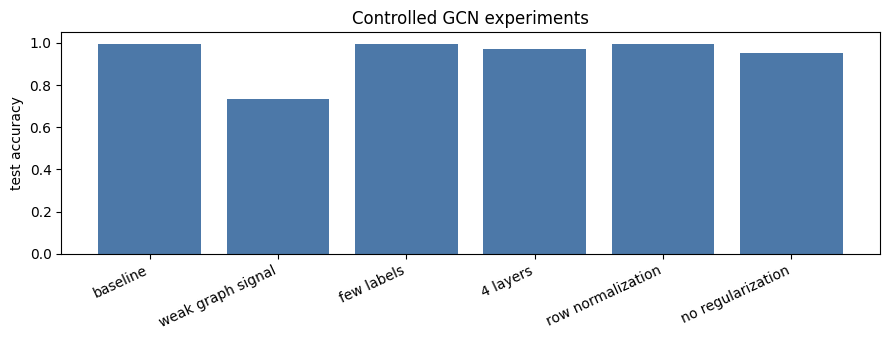

In [37]:
class DeepGCN(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, depth: int = 2, dropout: float = 0.5):
        super().__init__()
        if depth < 2:
            raise ValueError("depth must be at least 2")
        dims = [in_dim] + [hidden_dim] * (depth - 1) + [out_dim]
        self.layers = nn.ModuleList(GCNLayer(dims[i], dims[i + 1]) for i in range(depth))
        self.dropout = dropout

    def forward(self, x: torch.Tensor, adj_norm: torch.Tensor) -> torch.Tensor:
        for layer in self.layers[:-1]:
            x = F.relu(layer(x, adj_norm))
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.layers[-1](x, adj_norm)


def normalize_adjacency_variant(adj: torch.Tensor, method: str = "symmetric") -> torch.Tensor:
    adj_tilde = adj + torch.eye(adj.size(0), device=adj.device)
    degree = adj_tilde.sum(dim=1)
    if method == "symmetric":
        degree_inv_sqrt = degree.clamp_min(1).pow(-0.5)
        return degree_inv_sqrt[:, None] * adj_tilde * degree_inv_sqrt[None, :]
    if method == "row":
        return adj_tilde / degree.clamp_min(1)[:, None]
    raise ValueError(f"unknown normalization: {method}")


def run_gcn_experiment(
    graph_data: GraphData, depth: int = 2, normalization: str = "symmetric",
    dropout: float = 0.5, weight_decay: float = 5e-4, epochs: int = 150, seed: int = 42,
):
    set_seed(seed)
    current = GraphData(**{name: getattr(graph_data, name).to(device) for name in GraphData.__dataclass_fields__})
    current_adj_norm = normalize_adjacency_variant(current.adj, normalization)
    num_classes = int(current.y.max().item()) + 1
    current_model = DeepGCN(current.x.size(1), 32, num_classes, depth, dropout).to(device)
    optimizer = torch.optim.Adam(current_model.parameters(), lr=0.01, weight_decay=weight_decay)
    best_val_acc, best_state = -1.0, None

    for _ in range(epochs):
        current_model.train()
        optimizer.zero_grad()
        logits = current_model(current.x, current_adj_norm)
        loss = F.cross_entropy(logits[current.train_mask], current.y[current.train_mask])
        loss.backward()
        optimizer.step()

        current_model.eval()
        with torch.no_grad():
            logits = current_model(current.x, current_adj_norm)
            val_acc = accuracy(logits, current.y, current.val_mask)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {name: value.detach().cpu().clone() for name, value in current_model.state_dict().items()}

    current_model.load_state_dict({name: value.to(device) for name, value in best_state.items()})
    current_model.eval()
    with torch.no_grad():
        test_logits = current_model(current.x, current_adj_norm)
        test_acc = accuracy(test_logits, current.y, current.test_mask)
    return {"val_acc": best_val_acc, "test_acc": test_acc}


experiment_specs = [
    {"name": "baseline"},
    {"name": "weak graph signal", "p_in": 0.07, "p_out": 0.06},
    {"name": "few labels", "train_per_class": 2},
    {"name": "4 layers", "depth": 4},
    {"name": "row normalization", "normalization": "row"},
    {"name": "no regularization", "dropout": 0.0, "weight_decay": 0.0},
]

experiment_results = []
for spec in experiment_specs:
    set_seed(42)
    generated = make_sbm_node_classification(
        p_in=spec.get("p_in", 0.12),
        p_out=spec.get("p_out", 0.015),
        train_per_class=spec.get("train_per_class", 10),
    )
    result = run_gcn_experiment(
        generated, depth=spec.get("depth", 2),
        normalization=spec.get("normalization", "symmetric"),
        dropout=spec.get("dropout", 0.5),
        weight_decay=spec.get("weight_decay", 5e-4),
    )
    experiment_results.append({"name": spec["name"], **result})

print(f'{"condition":<22} {"validation":>11} {"test":>8}')
for row in experiment_results:
    print(f'{row["name"]:<22} {row["val_acc"]:>11.3f} {row["test_acc"]:>8.3f}')

plt.figure(figsize=(9, 3.5))
names = [row["name"] for row in experiment_results]
test_scores = [row["test_acc"] for row in experiment_results]
plt.bar(names, test_scores, color="#4C78A8")
plt.ylabel("test accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.title("Controlled GCN experiments")
plt.tight_layout()
plt.show()

## 11. 追加モデル: GraphSAGEを学習・検証する

ここではGCNとGraphSAGEを同じデータ分割で比較します。どちらも半教師ありノード分類ですが、層の中で行っている集約が違います。

- **GCN**: 正規化隣接行列で、自分と近傍の特徴を次数で補正しながら混ぜる
- **GraphSAGE**: 自分の特徴と、近傍特徴の平均を別々に持ち、連結してから学習する

この実装では、外部GNNライブラリを使わずに平均集約版GraphSAGEをPyTorchだけで書きます。大規模グラフでは近傍サンプリングを併用することが多いですが、この教材のサイズでは全近傍の平均を使います。


model         validation     test
GCN                1.000    0.993
GraphSAGE          1.000    0.971


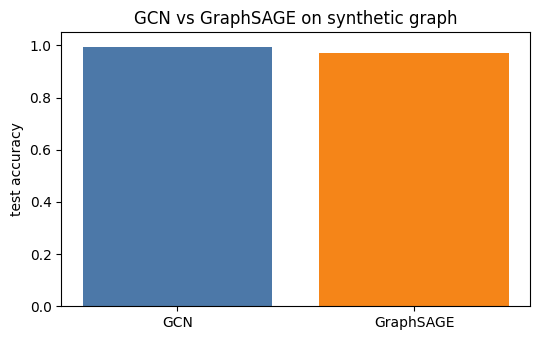

In [38]:
class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim: int, out_dim: int):
        super().__init__()
        self.linear = nn.Linear(in_dim * 2, out_dim)

    def forward(self, x: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        degree = adj.sum(dim=1, keepdim=True).clamp_min(1)
        neighbor_mean = adj @ x / degree
        return self.linear(torch.cat([x, neighbor_mean], dim=1))


class GraphSAGE(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, dropout: float = 0.5):
        super().__init__()
        self.layer1 = GraphSAGELayer(in_dim, hidden_dim)
        self.layer2 = GraphSAGELayer(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.layer1(x, adj))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.layer2(x, adj)


def run_graphsage_experiment(
    graph_data: GraphData, hidden_dim: int = 32, dropout: float = 0.5,
    weight_decay: float = 5e-4, epochs: int = 150, seed: int = 42,
):
    set_seed(seed)
    current = GraphData(**{name: getattr(graph_data, name).to(device) for name in GraphData.__dataclass_fields__})
    num_classes = int(current.y.max().item()) + 1
    current_model = GraphSAGE(current.x.size(1), hidden_dim, num_classes, dropout).to(device)
    optimizer = torch.optim.Adam(current_model.parameters(), lr=0.01, weight_decay=weight_decay)
    best_val_acc, best_state = -1.0, None

    for _ in range(epochs):
        current_model.train()
        optimizer.zero_grad()
        logits = current_model(current.x, current.adj)
        loss = F.cross_entropy(logits[current.train_mask], current.y[current.train_mask])
        loss.backward()
        optimizer.step()

        current_model.eval()
        with torch.no_grad():
            logits = current_model(current.x, current.adj)
            val_acc = accuracy(logits, current.y, current.val_mask)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {name: value.detach().cpu().clone() for name, value in current_model.state_dict().items()}

    current_model.load_state_dict({name: value.to(device) for name, value in best_state.items()})
    current_model.eval()
    with torch.no_grad():
        test_logits = current_model(current.x, current.adj)
        test_acc = accuracy(test_logits, current.y, current.test_mask)
    return {"val_acc": best_val_acc, "test_acc": test_acc}


set_seed(42)
comparison_data = make_sbm_node_classification()
gnn_comparison = [
    {"model": "GCN", **run_gcn_experiment(comparison_data, epochs=150, seed=42)},
    {"model": "GraphSAGE", **run_graphsage_experiment(comparison_data, epochs=150, seed=42)},
]

print(f'{"model":<12} {"validation":>11} {"test":>8}')
for row in gnn_comparison:
    print(f'{row["model"]:<12} {row["val_acc"]:>11.3f} {row["test_acc"]:>8.3f}')

plt.figure(figsize=(5.5, 3.5))
plt.bar([row["model"] for row in gnn_comparison], [row["test_acc"] for row in gnn_comparison], color=["#4C78A8", "#F58518"])
plt.ylabel("test accuracy")
plt.ylim(0, 1.05)
plt.title("GCN vs GraphSAGE on synthetic graph")
plt.tight_layout()
plt.show()


## 12. 実世界データ: Cora引用ネットワーク

Coraは機械学習論文の引用ネットワークです。論文をノード、引用をエッジ、論文に現れる単語をノード特徴量として、各論文の研究分野を予測します。合成グラフと異なり、接続も特徴量も実際の論文から作られています。

次の2ファイルをノートブックから見て以下の位置へ配置してください。追加パッケージは不要です。

```text
data/cora/cora.content  # 論文ID、単語特徴量、分野ラベル
data/cora/cora.cites    # 引用元ID、引用先ID
```

これは transductive な半教師ありノード分類です。全論文の特徴と引用構造を集約に使いますが、損失計算には各分野20件の訓練ラベルだけを使います。検証データで最良の時点を選び、テストデータは最後の評価にのみ使います。


classes: {0: 'Case_Based', 1: 'Genetic_Algorithms', 2: 'Neural_Networks', 3: 'Probabilistic_Methods', 4: 'Reinforcement_Learning', 5: 'Rule_Learning', 6: 'Theory'}
nodes: 2708
edges: 5278
avg degree: 3.90
min/max degree: 1 / 168
model         validation     test
GCN                0.800    0.790
GraphSAGE          0.805    0.757


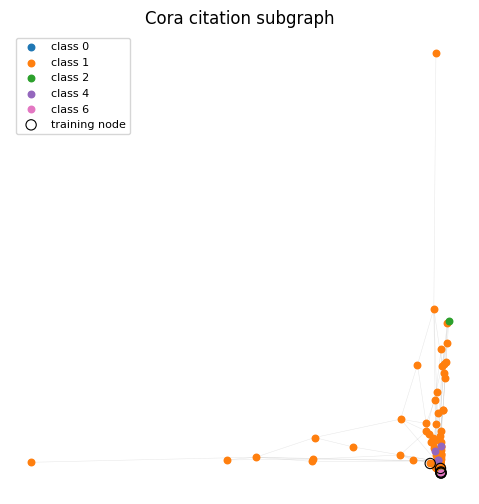

In [39]:
cora_dir = Path("data/cora")
if (cora_dir / "cora.content").exists() and (cora_dir / "cora.cites").exists():
    cora = load_cora(cora_dir, graph_data_cls=GraphData)
    describe_graph(cora.adj)
    cora_gcn_result = run_gcn_experiment(cora, epochs=200)
    cora_sage_result = run_graphsage_experiment(cora, epochs=200)
    print(f'{"model":<12} {"validation":>11} {"test":>8}')
    for row in [
        {"model": "GCN", **cora_gcn_result},
        {"model": "GraphSAGE", **cora_sage_result},
    ]:
        print(f'{row["model"]:<12} {row["val_acc"]:>11.3f} {row["test_acc"]:>8.3f}')

    sample_indices = neighborhood_sample(cora.adj)
    sample = GraphData(
        x=cora.x[sample_indices], y=cora.y[sample_indices],
        adj=cora.adj[sample_indices][:, sample_indices],
        train_mask=cora.train_mask[sample_indices], val_mask=cora.val_mask[sample_indices],
        test_mask=cora.test_mask[sample_indices],
    )
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_multiclass_graph(sample.adj, sample.y, sample.train_mask, ax)
    ax.set_title("Cora citation subgraph")
    plt.show()
else:
    print("Coraデータを実行するには data/cora/cora.content と data/cora/cora.cites を配置してください。")



## まとめ

GCNは、正規化隣接行列によって近傍情報を混ぜ、線形変換と非線形変換を重ねるシンプルなGNNです。

$$
H^{(l+1)} = \sigma\left(\hat{A} H^{(l)} W^{(l)}\right)
$$

実践上は、次の観点が重要です。

- グラフ構造がラベルや特徴量と整合しているか
- 自己ループと正規化をどう設計するか
- 層を深くしすぎて表現が平滑化されていないか
- 訓練・検証・テストの分割がタスク設定に合っているか
- 大規模グラフでは疎行列演算や近傍サンプリングが必要か

GCNはGNNの基礎として非常に重要ですが、実データではGraphSAGE、GAT、GIN、MPNN、R-GCNなど、グラフの種類やタスクに応じたモデル選択が必要になります。